<a target="_blank" rel="noopener noreferrer" href="https://colab.research.google.com/github/ccaudek/ds4psy_2023/blob/main/51_stan_two_groups_binom.ipynb">![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)</a>

(stan-two-groups-binom)=
# Due gruppi binomiali con Stan

In questo capitolo, ripeteremo l'esercizio relativo al confronto tra due gruppi i cui dati seguono la distribuzione binomiale. Useremo Stan anziché PyMC.

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import arviz as az
from cmdstanpy import cmdstan_path, CmdStanModel

In [2]:
%config InlineBackend.figure_format = 'retina'
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

In [3]:
n1 = 155
y1 = 108
n2 = 57
y2 = 28

Creaiamo un dizionario con i dati necessari per Stan.

In [7]:
data = {
    "N1" : n1,
    "y1" : y1,
    "N2" : n2,
    "y2" : y2
}

print(data)

{'N1': 155, 'y1': 108, 'N2': 57, 'y2': 28}


Leggiamo il codice Stan che implementa il modello descritto nel capitolo {ref}`hier_beta_binom_model`.

In [8]:
stan_file = os.path.join('stan', 'two_groups_binomial.stan')
with open(stan_file, 'r') as f:
    print(f.read())

//  Comparison of two groups with Binomial
data {
  int<lower=0> N1; // number of experiments in group 1
  int<lower=0> y1; // number of deaths in group 1
  int<lower=0> N2; // number of experiments in group 2
  int<lower=0> y2; // number of deaths in group 2
}
parameters {
  real<lower=0, upper=1> theta1; // probability of death in group 1
  real<lower=0, upper=1> theta2; // probability of death in group 2
}
model {
  // model block creates the log density to be sampled
  theta1 ~ beta(2, 2); // prior
  theta2 ~ beta(2, 2); // prior
  y1 ~ binomial(N1, theta1); // observation model / likelihood
  y2 ~ binomial(N2, theta2); // observation model / likelihood
  // the notation using ~ is syntactic sugar for
  //  target += beta_lpdf(theta1 | 1, 1);       // lpdf for continuous theta1
  //  target += beta_lpdf(theta2 | 1, 1);       // lpdf for continuous theta2
  //  target += binomial_lpmf(y1 | N1, theta1); // lpmf for discrete y1
  //  target += binomial_lpmf(y2 | N2, theta2); // lpmf f

Compiliamo il modello.

In [9]:
model = CmdStanModel(stan_file=stan_file)
print(model)

20:19:03 - cmdstanpy - INFO - compiling stan file /Users/corradocaudek/_repositories/ds4p/chapter_4/stan/two_groups_binomial.stan to exe file /Users/corradocaudek/_repositories/ds4p/chapter_4/stan/two_groups_binomial
20:19:14 - cmdstanpy - INFO - compiled model executable: /Users/corradocaudek/_repositories/ds4p/chapter_4/stan/two_groups_binomial


CmdStanModel: name=two_groups_binomial
	 stan_file=/Users/corradocaudek/_repositories/ds4p/chapter_4/stan/two_groups_binomial.stan
	 exe_file=/Users/corradocaudek/_repositories/ds4p/chapter_4/stan/two_groups_binomial
	 compiler_options=stanc_options={}, cpp_options={}


Eseguiamo il campionamento MCMC.

In [10]:
fit = model.sample(
    data=data,
    iter_sampling = 4000,
    iter_warmup = 2000,
    seed = 84735,
    chains = 4
)

20:19:17 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |██████████| 00:00 Sampling completed
chain 2 |██████████| 00:00 Sampling completed
chain 3 |██████████| 00:00 Sampling completed
chain 4 |██████████| 00:00 Sampling completed


20:19:17 - cmdstanpy - INFO - CmdStan done processing.


Esaminiamo le stime a posteriori dei parametri.

In [11]:
az.summary(fit, var_names=(["oddsratio"]), hdi_prob=0.94)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
oddsratio,2.44,0.773,1.149,3.86,0.007,0.005,13004.0,10374.0,1.0


I risultati ottenuti replicano quelli trovati con PyMC.

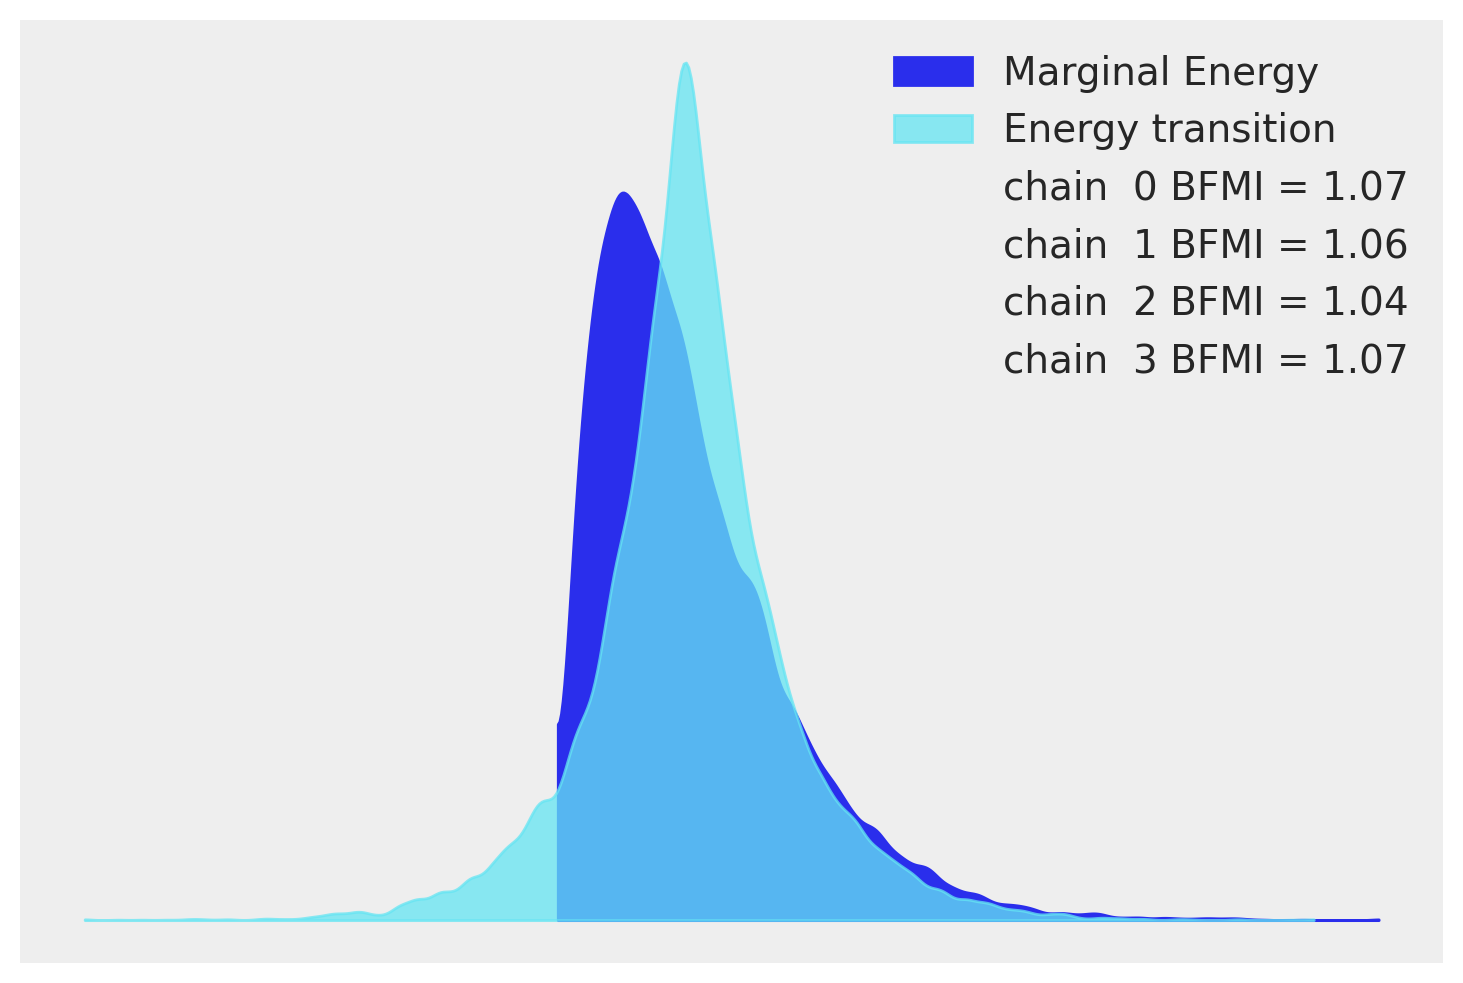

In [12]:
_ = az.plot_energy(fit)

## Watermark

In [13]:
%load_ext watermark
%watermark -n -u -v -iv -w -m -p cmdstanpy 

Last updated: Tue Mar 12 2024

Python implementation: CPython
Python version       : 3.12.2
IPython version      : 8.22.2

cmdstanpy: 1.2.1

Compiler    : Clang 16.0.6 
OS          : Darwin
Release     : 23.4.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit

numpy     : 1.26.4
matplotlib: 3.8.3
seaborn   : 0.13.2
pandas    : 2.2.1
scipy     : 1.12.0
arviz     : 0.17.0

Watermark: 2.4.3

